## Logistic Regression

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import copy, math

### 2 - Logistic Regression

#### 2.1 Problem statement 

Suppose that you are the administrator of a university department and you want to determine each applicant's chance of admission based on their results on two exams. 
* You have historical data from previous applicants that you can use as a training set for a logisstic regression
* For each training example, you have the applicant's score on two exams and the admissions decision
* Your task is to build a classfication model that estimates an applicant's probability of admission based on the scores from those two exams.

In [7]:
def load_data(file): 
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    X = data[:, :2]
    y = data[:, 2]
    return X, y

In [13]:
# load dataset
X_train, y_train = load_data("../data/ex2data1.txt")

In [14]:
print("First five elements in X_train:\n", X_train[:5])

First five elements in X_train:
 [[30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]
 [45.08327748 56.31637178]]


#### Check the dimensoin of the variables 
Another useful way to get familiar with the data is to view its dimensions. Let's print the shape of `X_train` and `y_train` and see how many training examples we have in our dataset.

In [16]:
print('The shape of X_train is: ' + str(X_train.shape))
print('The shape of y_train is: ' + str(y_train.shape))
print('We have m = %d training examples' %(len(y_train)))

The shape of X_train is: (99, 2)
The shape of y_train is: (99,)
We have m = 99 training examples


#### Visualize the data 
Before starting to implement any learning algorithm, it is always good to visualize the data if possible 
* The code below displays the data on a 2D plot, where the axes are the two exam scores, and the positive and negative examples are shown with different markers.

In [24]:
def plot_data(X, y, pos_label = 'y = 1', neg_label = 'y = 0', loc='best'): 
    pos = (y == 1)
    neg = (y == 0)

    pos = pos.reshape(-1,)
    neg = neg.reshape(-1,)

    plt.plot(X[pos, 0], X[pos, 1], 'k+', label = pos_label)
    plt.plot(X[neg, 0], X[neg, 1], 'yo', label=neg_label)
    plt.legend(loc=loc)

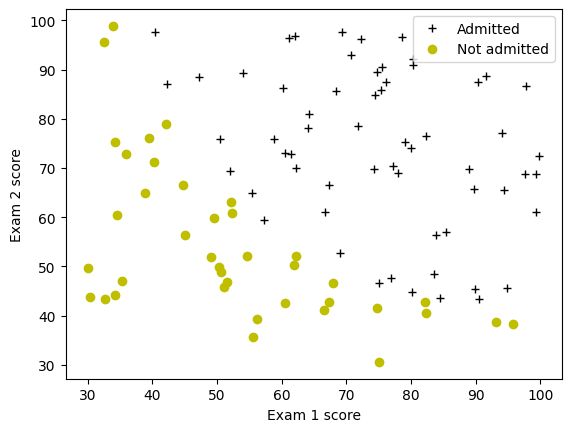

In [27]:
# Plot examples
plot_data(X_train, y_train, pos_label="Admitted", neg_label="Not admitted", loc="upper right")

# Set the y-axis label
plt.ylabel('Exam 2 score')
plt.xlabel('Exam 1 score')
plt.show()

#### 2.3 Sigmoid function 
Recall that for logistic regression, the model is represented as 
    $$f_{w, b}(x) = g(\mathbf{w}\cdot\mathbf{x} + b)$$
where function g is the sigmoid funciton. The sigmoid function is defined as 
$$g(z) = \frac{1}{1 + e^{-z}}$$

## Exercise 1

Please complete the `sigmoid` function to calculate 
$$g(z) = \frac{1}{1 + e^{-z}}$$

Note that 
* `z` is not always a single number, but can also be an array of numbers
* If the input is an array of numbers, we'd like to apply the sigmoid function to each value in the input array.

In [28]:
def sigmoid(z): 
    g = 1 / (1 + np.exp(-z))
    return g

In [31]:
value = 0

print(f"sigmoid ({value}) = {sigmoid(value)}")

sigmoid (0) = 0.5


**Expected Output** 
<table>
    <tr> 
        <td><b>sigmoid(0)</b></td>
        <td> 0.5</td>
    </tr>
</table>

In [32]:
print ("sigmoid([-1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

sigmoid([-1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]


<table>
    <tr>
        <td><b>sigmoid([-1, 0, 1, 2])</b> </td>
        <td> [0.26894142 0.5        0.73105858 0.88079708] </td>
    </tr>    
</table>

#### 2.4 Cost function for logistic regression

Please complete the `compute cost` function using the equations below
Recall that for logistic regression, the cost function is of the form
$$J(\mathbf{w}, b) = \frac{1}{m}\sum\limits_{i = 0}^{m - 1}[loss(f_{w, b}(\mathbf{x}^{(i)}), y^{(i)})]\tag{1}$$

where
* m is the number of training examples in the dataset
* $loss(f_{w, b}, y^{(i)})$ is the cost for a single data point, which is
$$loss(f_{w, b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)})log(f_{w, b}(\mathbf{x}^{(i)})) - (1 - y^{(i)})log(1 - f_{w, b}(\mathbf{x}^{(i)})$$

Note: 
* As we are doing this, remeber that the variables `X_train` and `y_train` are not scalar values but matrices of shape (m, n) and (m , 1) respectively, where n is the number of features and m is the number of training examples
* We can use the sigmoid function that we implemented above for this apart

In [69]:
# UNQ_C2
# GRADED FUNCTION: compute_cost
def compute_cost(X, y, w, b, *argv):
    """
    Computes the cost over all examples
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target value 
      w : (ndarray Shape (n,))  values of parameters of the model      
      b : (scalar)              value of bias parameter of the model
      *argv : unused, for compatibility with regularized version below
    Returns:
      total_cost : (scalar) cost 
    """

    m, n = X.shape
    
    cost = 0.0
    for i in range(m): 
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        cost = cost + (-y[i]*np.log(f_wb_i) - (1 - y[i])*np.log(1 - f_wb_i))                 
    total_cost = cost / m
    
    ### END CODE HERE ### 

    return total_cost

In [35]:
m, n = X_train.shape 
initial_w = np.zeros(n) 
initial_b = 0. 
cost = compute_cost(X_train, y_train, initial_w, initial_b) 
print('Cost at initial w and b (zeros): {:.3f}'.format(cost))

Cost at initial w and b (zeros): 0.693


**Expected Output** 
<table>
    <tr>
        <td><b> Cost at initial w and b (zeros)</b></td>
        <td> 0.693 </td>
    </tr>    
</table>

#### 2.5 Gradient for logistic regression
Recall that the gradient descent algorithm is 
$$\begin{align*} 
\text{repeat until convergence:}\lbrace\newline
\;\;\; & b := b - \alpha\frac{\partial J(\mathbf{w}, b)}{\partial b} \newline
\; & w_j := w_j - \alpha\frac{\partial J(\mathbf{w}, b)}{\partial w_j} & \text{for j := 0..n-1}\tag{1}\newline
\rbrace
\end{align*}$$

Please complete the `compute_gradient` function to compute $\frac{\partial J(\mathbf{w}, b)}{\partial w}$, $\frac{\partial J(\mathbf{w}, b)}{\partial b}$ from equations (2) and (3) below.

$$\frac{\partial J(\mathbf{w}, b)}{\partial b} = \frac{1}{m}\sum\limits_{i = 0}^{m - 1}(f_{w, b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})\tag{2}$$
$$\frac{\partial J(\mathbf{w}, b)}{\partial b} = \frac{1}{m}\sum\limits_{i = 0}^{m - 1}(f_{w, b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)}\tag{3}$$

* **Note**: While this gradient looks identical to the linear regression gradient, the formula is actually different because linear and logistic regression have different definitions of $f_{w, b}(x)$

In [72]:
# UNQ_C3
# GRADED FUNCTION: compute_gradient
def compute_gradient(X, y, w, b, *argv): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target value 
      w : (ndarray Shape (n,))  values of parameters of the model      
      b : (scalar)              value of bias parameter of the model
      *argv : unused, for compatibility with regularized version below
    Returns
      dj_dw : (ndarray Shape (n,)) The gradient of the cost w.r.t. the parameters w. 
      dj_db : (scalar)             The gradient of the cost w.r.t. the parameter b. 
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    ### START CODE HERE ### 
    for i in range(m):
        z_wb = np.dot(X[i], w) + b
        err = sigmoid(z_wb) - y[i]
        for j in range(n): 
            dj_dw[j] = dj_dw[j] + err*X[i, j]
        dj_db += err
        
            
    dj_dw = dj_dw /m
    dj_db = dj_db / m
    ### END CODE HERE ###

        
    return dj_db, dj_dw

In [41]:
initial_w = np.zeros(n) 
initial_b = 0.

dj_dw, dj_db = compute_gradient(X_train, y_train, initial_w, initial_b) 
print(f'dj_db at initial w and b (zeros): {dj_db}')
print(f'dj_dw at initial w and b (zeros): {dj_dw.tolist()}')

dj_db at initial w and b (zeros): -0.10606060606060606
dj_dw at initial w and b (zeros): [-12.305388775165389, -11.770672393525663]


**Expected Output** 
<table>
    <tr>
        <td><b> dj_db at initial w and b (zeros) </b></td>
        <td>-0.1</td>
    </tr>
    <tr>
        <td><b>dj_dw at initial w and b (zeros) </b></td>
        <td> [-12.305388775165389, -11.770672393525663] </td>
    </tr>
</table>

#### 2.6 Learning parameters using gradient descent

In [112]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X :    (ndarray Shape (m, n) data, m examples by n features
      y :    (ndarray Shape (m,))  target value 
      w_in : (ndarray Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)              Initial value of parameter of the model
      cost_function :              function to compute cost
      gradient_function :          function to compute gradient
      alpha : (float)              Learning rate
      num_iters : (int)            number of iterations to run gradient descent
      lambda_ : (scalar, float)    regularization constant
      
    Returns:
      w : (ndarray Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

In [74]:
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2) - 0.5)
initial_b = -8 

iterations = 10000
alpha = 0.001

w, b, J_history, _ = gradient_descent(X_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations, 0)

Iteration    0: Cost     0.94   
Iteration 1000: Cost     0.30   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   


#### 2.7 Plotting the decision boundary

In [120]:
def plot_decision_boundary(w, b, X, y): 
    
    plot_data(X[:, 0:2], y)
    
    if X.shape[1] <= 2:
        plot_x = np.array([min(X[:, 0]), max(X[:, 0])])
        plot_y = (-1. / w[1]) * (w[0] * plot_x + b)
        
        plt.plot(plot_x, plot_y, c="b")
        
    else:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)
        
        z = np.zeros((len(u), len(v)))

        # Evaluate z = theta*x over the grid
        for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = sigmoid(np.dot(map_feature(u[i], v[j]), w) + b)
        
        # important to transpose z before calling contour       
        z = z.T
        
        # Plot z = 0.5
        plt.contour(u,v,z, levels = [0.5], colors="g")

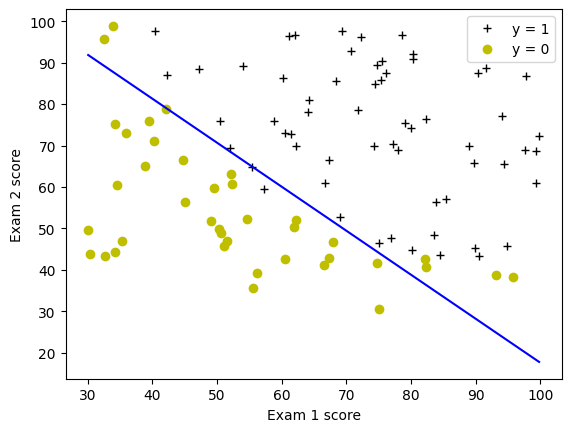

In [79]:
plot_decision_boundary(w, b, X_train, y_train)
plt.ylabel('Exam 2 score')
plt.xlabel('Exam 1 score')
plt.legend(loc='best') 
plt.show()

In [80]:
def predict(X, w, b): 
    m, n = X.shape 
    p = np.zeros(m) 

    for i in range(m): 
        z_wb = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_wb)

        if f_wb_i >= 0.5: 
            p[i] = 1
    return p

In [85]:
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3 
tmp_X = np.random.randn(4, 2) - 0.5
tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape{tmp_p.shape}, value {tmp_p}')

Output of predict: shape(4,), value [0. 1. 1. 1.]


In [87]:
p = predict(X_train, w, b)
print('Train accuracy: %f'%(np.mean(p == y_train)*100))

Train accuracy: 91.919192


### 3- Regularized Logistic Regression

#### 3.1 Problem Statement 
Suppose you are the product manager of the factory and you have the test results for some microchips on two different tests
* From these two tests, you would like to determine whether the microchips should be accepted or rejected.
* To help you make the the decision, you have a dataset of test results on past microchips, from which you can build a logistic regression model. 

In [88]:
# load dataset
X_train, y_train = load_data("../data/ex2data2.txt")

In [95]:
## print X_train 
print("X_train: ", X_train[:5])
print("\ny_train: ", y_train[:5])

X_train:  [[-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]
 [-0.52477   0.2098  ]]

y_train:  [1. 1. 1. 1. 1.]


#### Visualize the data

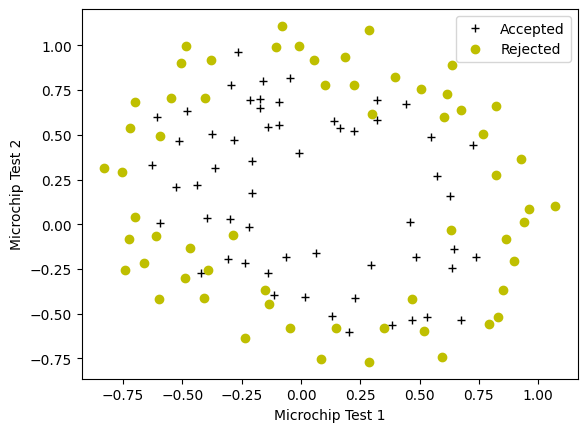

In [93]:
# Plot examples
plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

plt.ylabel('Microchip Test 2')

plt.xlabel('Microchip Test 1')
plt.legend(loc="upper right")
plt.show()

Figure 3 shows that our dataset cannot be separated into positive and negative examples by a straight-line through the plot. Therefore, a straightforward application of logisitc regression will not perform well on this dataset since logistic regression will only be able to find a linear regression boundary.

#### 3.3 Feature mapping

One way to fit the data better is to create more features from each data point. In the provided function `map_feature`, we will map the features into all polynomial terms of $x_1$ and $x_2$ up to the sixth power. 

$$\mathrm{map\_feature}(x) = 
\left[\begin{array}{c}
x_1\\
x_2\\
x_1^2\\
x_1 x_2\\
x_2^2\\
x_1^3\\
\vdots\\
x_1 x_2^5\\
x_2^6\end{array}\right]$$

As a result of this mapping, our vector of two features (the scores on two QA tests) has been transformed into a 27 dimensional vector

- A logisitic regression classifier trained on this higher-dimension feature vector will have a more complex decision boundary and will be nonlinear when drawn in our 2-dimensional plot.
- We have provided the `map_feature` function. 

In [96]:
def map_feature(X1, X2): 
    """
    Feature mapping function to polynomial features
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2) 
    degree = 6
    out = []
    for i in range(1, degree + 1): 
        for j in range(i + 1): 
            out.append((X1 ** (i - j) * (X2**j)))
    return np.stack(out, axis=1)

In [98]:
print("Original shape of data:", X_train.shape)

mapped_X = map_feature(X_train[:, 0], X_train[:, 1])
print("Shapped after feature mapping:", mapped_X.shape)

Original shape of data: (117, 2)
Shapped after feature mapping: (117, 27)


In [99]:
print("X_train[0]", X_train[0])
print("mapped X_trained[0]", mapped_X[0])

X_train[0] [-0.092742  0.68494 ]
mapped X_trained[0] [-9.27420000e-02  6.84940000e-01  8.60107856e-03 -6.35227055e-02
  4.69142804e-01 -7.97681228e-04  5.89122275e-03 -4.35092419e-02
  3.21334672e-01  7.39785525e-05 -5.46363780e-04  4.03513411e-03
 -2.98012201e-02  2.20094970e-01 -6.86091891e-06  5.06708697e-05
 -3.74226408e-04  2.76382476e-03 -2.04120477e-02  1.50751849e-01
  6.36295342e-07 -4.69931780e-06  3.47065055e-05 -2.56322636e-04
  1.89305413e-03 -1.39810280e-02  1.03255971e-01]


While the feature mapping allows us to build a more expressive classifier, it is also susceptible to overfitting.

In [101]:
def compute_cost_reg(X, y, w, b, lambda_ = 1): 
    m, n = X.shape 

    cost_without_reg = compute_cost(X, y, w, b)

    reg_cost = 0.

    for j in range(n): 
        reg_cost = reg_cost + (w[j])**2
    reg_cost = (lambda_/(2*m)) * reg_cost

    total_cost = cost_without_reg + reg_cost
    return total_cost

In [103]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5

cost = compute_cost_reg(X_mapped, y_train, initial_w, initial_b, lambda_) 
print("Regularized cost :", cost)

Regularized cost : 0.6631463327835964


In [115]:
def compute_gradient_reg(X, y, w, b, lambda_ = 1): 
    m, n = X.shape 
    dj_db, dj_dw = compute_gradient(X, y, w, b)

    for j in range(n): 
        dj_dw[j] = dj_dw[j] + (lambda_ / m) * w[j]

    return dj_db, dj_dw

In [118]:
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 1 

lambda_ = 0.5
iterations = 10000
alpha = 0.01 

w, b, J_history, _ = gradient_descent(X_mapped, y_train, initial_w, initial_b, compute_cost_reg, compute_gradient_reg, alpha, iterations, lambda_)

Iteration    0: Cost     0.73   
Iteration 1000: Cost     0.60   
Iteration 2000: Cost     0.57   
Iteration 3000: Cost     0.55   
Iteration 4000: Cost     0.54   
Iteration 5000: Cost     0.53   
Iteration 6000: Cost     0.52   
Iteration 7000: Cost     0.51   
Iteration 8000: Cost     0.51   
Iteration 9000: Cost     0.50   
Iteration 9999: Cost     0.50   


/var/folders/47/c_w9jlv53lgdn8fb4nhx6smr0000gn/T/ipykernel_16054/516985309.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] = sigmoid(np.dot(map_feature(u[i], v[j]), w) + b)


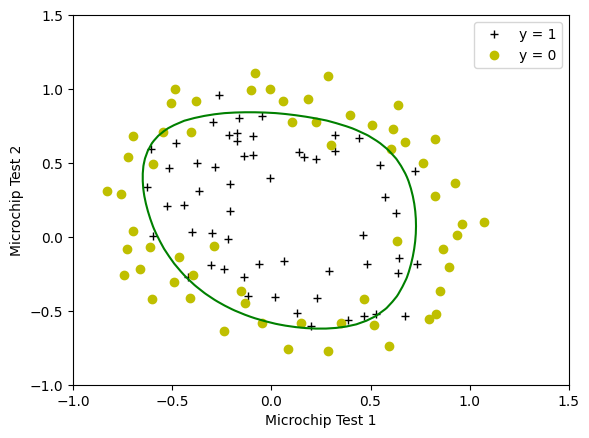

In [125]:
plot_decision_boundary(w, b, X_mapped, y_train)

plt.ylabel('Microchip Test 2')
plt.xlabel('Microchip Test 1')
plt.legend(loc='best')
plt.show()

In [127]:
p = predict(X_mapped, w, b)

print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 82.905983
